# Fase 1: Comprensión del Negocio (Business Understanding)
**Proyecto:** FruitVision — Sistema de Clasificación Automática de Calidad de Frutas 
**Curso:** Algoritmos y Programación III — Semestre 2026-1 
**Integrantes:** Juan José Gordillo Córdoba · Sebastián Jiménez Galvis · Juan Pablo Zambrano Cortez 
**Metodología:** CRISP-DM — Fase 1 de 6 
**Fecha:** Mayo 2026

---

## 1. Contexto del problema

### 1.1 Descripción del dominio

La clasificación de calidad de frutas y verduras es un proceso crítico en la cadena agroalimentaria colombiana. Actualmente, este proceso se realiza de forma **manual** por operarios en plazas de mercado, centrales de abastos y plantas de empaque. En Cali, la Central de Abastos (Cavasa) moviliza diariamente más de 3.000 toneladas de productos frescos, muchos de los cuales son descartados o subvalorados porque no existe un criterio uniforme de clasificación entre los diferentes puestos de venta.

El proceso manual concentra tres deficiencias estructurales que se refuerzan entre sí: la subjetividad de cada operario introduce una variación del 15–25% en los criterios de clasificación respecto a sus compañeros; la velocidad humana de inspección (~200 unidades/hora) es un orden de magnitud inferior a la de sistemas automáticos (>2.000 unidades/hora); y la fatiga acumulada en jornadas superiores a seis horas eleva la tasa de error hasta un 40%. El resultado combinado es un flujo de producto mal categorizado que genera pérdidas económicas evitables en toda la cadena.

| Deficiencia | Impacto medible |
|-------------|----------------|
| **Subjetividad** del operario | Variación del 15–25% en criterios entre operarios distintos |
| **Velocidad** limitada | ~200 unidades/hora vs. >2.000 en sistemas automáticos |
| **Fatiga** acumulada | Tasa de error hasta 40% en jornadas >6 horas |

### 1.2 Relevancia económica

Según la FAO (2022), el 30% de los alimentos producidos globalmente se pierde o desperdicia antes de llegar al consumidor, y una fracción significativa ocurre en la fase de clasificación y empaque. En Colombia, el DANE estima pérdidas post-cosecha de entre el 20% y el 40% para frutas perecederas, lo que representa millones de toneladas de alimento y valor económico que nunca llegan al mercado.

Un sistema de visión artificial que estandarice la clasificación puede reducir ese desperdicio entre un 10% y un 20% al identificar con mayor precisión las frutas aptas para cada canal de venta: los productos Premium correctamente detectados alcanzan mejores precios en supermercados de cadena y exportación, mientras que los clasificados como Estándar se redirigen a mercados locales antes de degradarse. En conjunto, la mayor eficiencia reduce costos laborales en líneas de empaque de mediana y gran escala.

### 1.3 Relevancia social

El impacto del proyecto va más allá del ahorro económico empresarial. En primer lugar, reducir el desperdicio amplía la disponibilidad de alimentos en mercados populares, con efecto directo sobre la seguridad alimentaria de los sectores de menores ingresos. En segundo lugar, una versión móvil de la herramienta permitiría a pequeños productores rurales conocer el valor real de su cosecha antes de negociar con intermediarios, reduciendo la asimetría de información que históricamente ha operado en su contra. En tercer lugar, la estandarización facilita el cumplimiento de la norma NTC 4580, requisito para la exportación de frutas colombianas, abriendo mercados internacionales a productores que hoy no pueden certificar su calidad de manera objetiva.

---

## 2. Definición del problema de analítica

### 2.1 Formulación formal

El problema se enmarca como una tarea de **clasificación multiclase supervisada sobre imágenes**: dado un frame RGB de una fruta individual capturado sobre fondo simple, el sistema debe predecir a cuál de tres categorías de calidad pertenece. La restricción operativa de ejecutar el modelo en hardware estándar (laptop o Raspberry Pi) condiciona la selección de arquitecturas e impone límites explícitos de latencia que se detallan en los criterios de éxito.

| Elemento | Descripción |
|----------|-------------|
| **Entrada** | Imagen estática RGB de una fruta individual sobre fondo simple |
| **Salida** | Clase de calidad ∈ {Premium, Estándar, Descarte} |
| **Restricción** | Ejecutable en hardware estándar; latencia <2 s/imagen |
| **Tipo de problema** | Clasificación multiclase supervisada |

### 2.2 Definición operativa de las clases

Cada clase debe tener criterios visuales objetivos, medibles y replicables por los tres integrantes del equipo al momento de etiquetar las imágenes propias. Los umbrales cuantitativos —diámetro de mancha, porcentaje de superficie afectada— se establecieron a partir de la norma NTC 4580 y de referencias de clasificación comercial de frutas en centrales de abastos colombianas. Sin esta operativización explícita, el etiquetado manual producirá inconsistencias que el modelo aprenderá como ruido, degradando su capacidad de generalización.

| Clase | Código | Criterio visual objetivo | Destino comercial |
|-------|--------|--------------------------|-------------------|
| **Premium** | 0 | Color uniforme y característico de la especie, sin manchas, forma regular, sin golpes visibles | Exportación, supermercados de cadena |
| **Estándar** | 1 | Hasta 2 manchas de diámetro <1 cm, deformaciones que no afecten más del 10% de la superficie, sin podredumbre | Mercados locales, procesamiento |
| **Descarte** | 2 | Podredumbre visible, golpes >30% de la superficie, deformación estructural, presencia de hongos o plagas | Compostaje, desecho |

> **Acuerdo de etiquetado:** en caso de duda sobre la clase de una imagen, los tres integrantes votan y se registra la decisión mayoritaria junto con el nivel de desacuerdo. Las imágenes con desacuerdo total se segregan en un subconjunto de análisis de ambigüedad.

### 2.3 Salida adicional — Estimación de tamaño

El enunciado requiere estimar también el tamaño relativo de la fruta, tarea que se abordará como un segundo objetivo una vez que el clasificador de calidad alcance el umbral mínimo de desempeño. La estimación se basa en el diámetro aparente del objeto en la imagen normalizada a 224×224 px, lo que introduce una dependencia con la distancia de captura que deberá controlarse mediante el protocolo de recolección de imágenes propias.

| Categoría | Criterio en imagen normalizada |
|-----------|-------------------------------|
| Pequeño | Diámetro aparente <80 px |
| Mediano | Entre 80 px y 150 px |
| Grande | >150 px |

---

## 3. Objetivos del proyecto

### 3.1 Objetivo general

Desarrollar un sistema de visión por computadora capaz de clasificar automáticamente la calidad de frutas en tres categorías (Premium, Estándar, Descarte) a partir de imágenes estáticas, con desempeño validado sobre datos heterogéneos (Kaggle + recolección propia en Cali).

### 3.2 Objetivos específicos

Los siguientes objetivos operativizan el general en entregables verificables por fase de CRISP-DM:

1. **Análisis exploratorio (Fase 2):** caracterizar estadísticamente el dataset combinado —distribución de clases, propiedades visuales, grado de desbalanceo— y documentar los hallazgos que condicionarán las decisiones de preprocesamiento y modelado.

2. **Pipeline de preprocesamiento (Fase 3):** implementar un pipeline reproducible de redimensionamiento, normalización y balanceo de clases que pueda invocarse de forma idéntica durante el entrenamiento y la inferencia, eliminando fuentes de data leakage.

3. **Modelado ML tradicional (Fase 4):** entrenar y optimizar mediante GridSearchCV al menos dos modelos clásicos (Random Forest y XGBoost) sobre características extraídas manualmente (histogramas HSV, LBP, momentos de textura).

4. **Modelado Deep Learning (Fase 4):** diseñar, entrenar y evaluar una CNN de tres capas convolucionales entrenada desde cero, sin transfer learning, para contrastar la capacidad de representación aprendida frente a las características manuales.

5. **Evaluación comparativa (Fase 5):** comparar todos los modelos usando accuracy, F1-macro, precisión y recall por clase, apoyados en matrices de confusión y análisis estadístico de diferencias entre paradigmas.

6. **Despliegue (Fase 6):** construir una interfaz Streamlit que permita cargar o capturar una imagen en tiempo real, mostrar la predicción junto con la distribución de probabilidades entre clases, y alertar al operario cuando la confianza del modelo sea baja.

### 3.3 Criterios de éxito

La métrica más crítica del proyecto es el **Recall de la clase Descarte**. Un falso negativo en esta clase —clasificar como Premium una fruta en descomposición— conlleva riesgos sanitarios y pérdidas económicas cualitativamente distintos a cualquier otro error del sistema: el producto podría llegar al consumidor final o contaminar lotes adyacentes en el empaque. Por esta razón, el umbral mínimo de Recall Descarte se fija en 0.80, por encima del estándar habitual de 0.75, y el umbral objetivo en 0.92. El resto de métricas establece el piso general de calidad del clasificador.

| Métrica | Umbral mínimo | Umbral objetivo |
|---------|--------------|----------------|
| Accuracy (test) | ≥ 75% | ≥ 88% |
| F1-macro (test) | ≥ 0.70 | ≥ 0.85 |
| Recall clase Descarte | ≥ 0.80 | ≥ 0.92 |
| Latencia de inferencia | < 2 s/imagen | < 500 ms |

---

## 4. Diagrama CRISP-DM personalizado del proyecto

El siguiente diagrama representa la aplicación concreta de CRISP-DM al proyecto FruitVision. La secuencia principal sigue el flujo F1 F2 F3 F4 F5 F6. La flecha discontinua amarilla de F5 hacia F4 representa el ciclo de retroalimentación: si las métricas de evaluación no superan los umbrales mínimos establecidos en la Sección 3.3, el equipo regresa a la fase de modelado para ajustar hiperparámetros o revisar el pipeline de preprocesamiento antes de intentar el despliegue. La caja central de Datos recuerda que tanto el dataset de Kaggle como las imágenes propias alimentan todas las fases intermedias, no únicamente la de modelado.

C:\Users\juanj\AppData\Local\Temp\ipykernel_35612\3281242563.py:101: UserWarning: Glyph 128452 (\N{FILE CABINET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\juanj\AppData\Local\Temp\ipykernel_35612\3281242563.py:102: UserWarning: Glyph 128452 (\N{FILE CABINET}) missing from font(s) DejaVu Sans.
  plt.savefig('../../reports/figures/crisp_dm_diagram.png',
C:\Users\juanj\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128452 (\N{FILE CABINET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


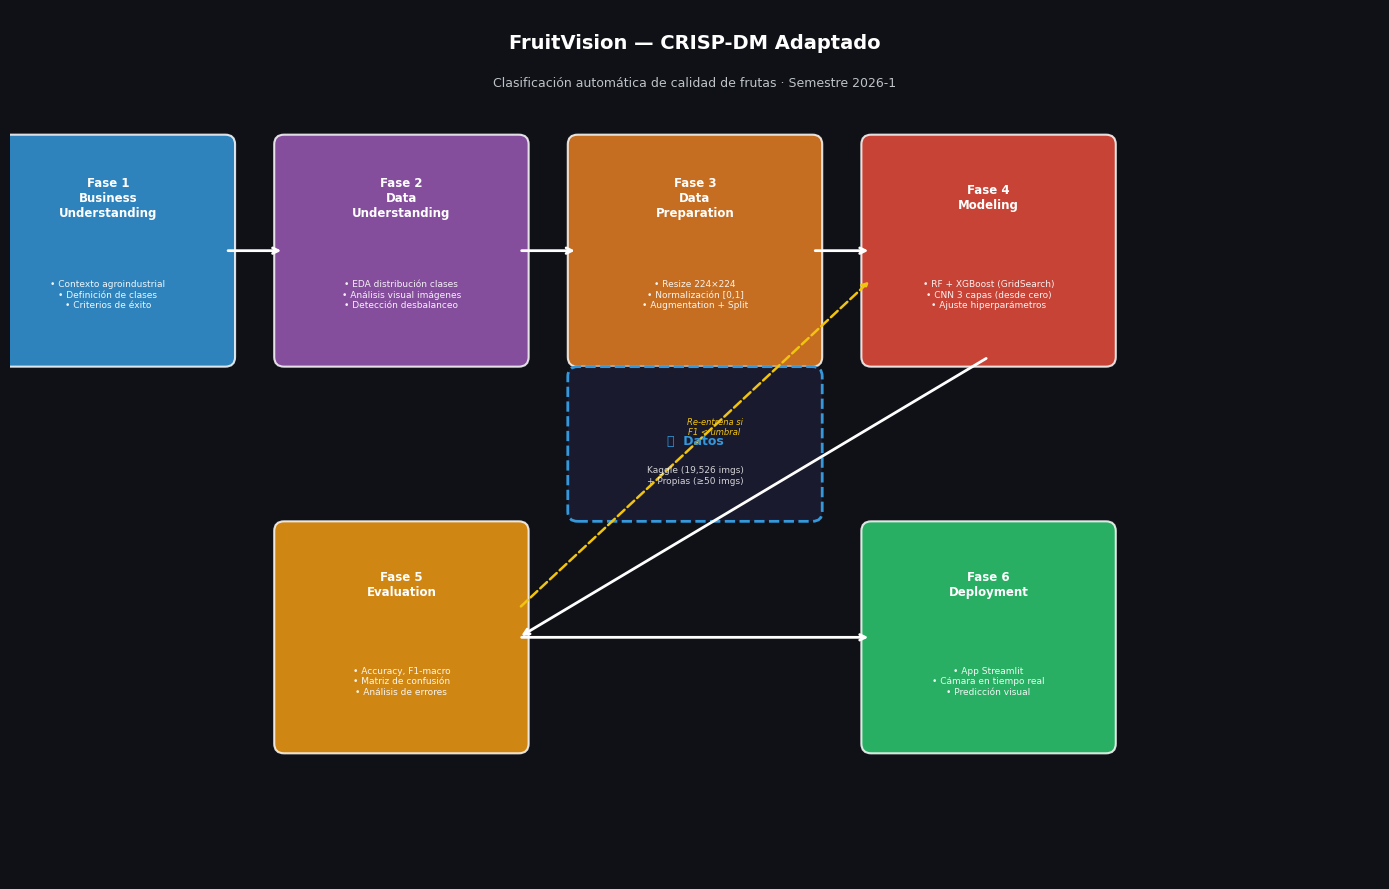

[✓] Diagrama guardado en reports/figures/crisp_dm_diagram.png


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(14, 9))
ax.set_xlim(0, 14)
ax.set_ylim(0, 9)
ax.axis('off')
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')

# Colores por fase
phase_colors = {
    'F1': '#3498db',  # Business Understanding
    'F2': '#9b59b6',  # Data Understanding
    'F3': '#e67e22',  # Data Preparation
    'F4': '#e74c3c',  # Modeling
    'F5': '#f39c12',  # Evaluation
    'F6': '#2ecc71',  # Deployment
}

phases = [
    ('F1', 'Fase 1\nBusiness\nUnderstanding',
     '• Contexto agroindustrial\n• Definición de clases\n• Criterios de éxito', 1.0, 6.5),
    ('F2', 'Fase 2\nData\nUnderstanding',
     '• EDA distribución clases\n• Análisis visual imágenes\n• Detección desbalanceo', 4.0, 6.5),
    ('F3', 'Fase 3\nData\nPreparation',
     '• Resize 224×224\n• Normalización [0,1]\n• Augmentation + Split', 7.0, 6.5),
    ('F4', 'Fase 4\nModeling',
     '• RF + XGBoost (GridSearch)\n• CNN 3 capas (desde cero)\n• Ajuste hiperparámetros', 10.0, 6.5),
    ('F5', 'Fase 5\nEvaluation',
     '• Accuracy, F1-macro\n• Matriz de confusión\n• Análisis de errores', 4.0, 2.5),
    ('F6', 'Fase 6\nDeployment',
     '• App Streamlit\n• Cámara en tiempo real\n• Predicción visual', 10.0, 2.5),
]

boxes = {}
for key, title, detail, x, y in phases:
    color = phase_colors[key]
    # Caja principal
    box = FancyBboxPatch((x-1.2, y-1.1), 2.4, 2.2,
                          boxstyle='round,pad=0.1',
                          facecolor=color, alpha=0.85,
                          edgecolor='white', linewidth=1.5)
    ax.add_patch(box)
    # Título
    ax.text(x, y+0.55, title, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white',
            multialignment='center')
    # Detalle
    ax.text(x, y-0.45, detail, ha='center', va='center',
            fontsize=6.5, color='white', alpha=0.92,
            multialignment='center')
    boxes[key] = (x, y)

# Flechas horizontales (F1→F2→F3→F4)
for src, dst in [('F1','F2'), ('F2','F3'), ('F3','F4')]:
    x1, y1 = boxes[src]
    x2, y2 = boxes[dst]
    ax.annotate('', xy=(x2-1.2, y2), xytext=(x1+1.2, y1),
                arrowprops=dict(arrowstyle='->', color='white',
                                lw=2, connectionstyle='arc3,rad=0'))

# Flecha F4 → F5 (bajada diagonal)
ax.annotate('', xy=(boxes['F5'][0]+1.2, boxes['F5'][1]),
            xytext=(boxes['F4'][0], boxes['F4'][1]-1.1),
            arrowprops=dict(arrowstyle='->', color='white', lw=2))

# Flecha F5 → F4 (retroalimentación — ciclo CRISP)
ax.annotate('', xy=(boxes['F4'][0]-1.2, boxes['F4'][1]-0.3),
            xytext=(boxes['F5'][0]+1.2, boxes['F5'][1]+0.3),
            arrowprops=dict(arrowstyle='->', color='#f1c40f',
                            lw=1.8, linestyle='dashed'))
ax.text(7.2, 4.6, 'Re-entrena si\nF1 < umbral', fontsize=6,
        color='#f1c40f', ha='center', style='italic')

# Flecha F5 → F6
ax.annotate('', xy=(boxes['F6'][0]-1.2, boxes['F6'][1]),
            xytext=(boxes['F5'][0]+1.2, boxes['F5'][1]),
            arrowprops=dict(arrowstyle='->', color='white', lw=2))

# Datos — caja central
data_box = FancyBboxPatch((5.8, 3.8), 2.4, 1.4,
                           boxstyle='round,pad=0.1',
                           facecolor='#1a1a2e', edgecolor='#3498db',
                           linewidth=2, linestyle='--')
ax.add_patch(data_box)
ax.text(7.0, 4.5, '🗄️  Datos', ha='center', fontsize=9,
        fontweight='bold', color='#3498db')
ax.text(7.0, 4.1, 'Kaggle (19,526 imgs)\n+ Propias (≥50 imgs)', ha='center',
        fontsize=6.5, color='white', alpha=0.8)

# Título general
ax.text(7.0, 8.6, 'FruitVision — CRISP-DM Adaptado',
        ha='center', fontsize=14, fontweight='bold',
        color='white')
ax.text(7.0, 8.2, 'Clasificación automática de calidad de frutas · Semestre 2026-1',
        ha='center', fontsize=9, color='#bdc3c7')

plt.tight_layout()
plt.savefig('../../reports/figures/crisp_dm_diagram.png',
            dpi=180, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('[✓] Diagrama guardado en reports/figures/crisp_dm_diagram.png')

---

## 5. Análisis de riesgos del proyecto

Los riesgos identificados en esta fase son los más previsibles con la información disponible antes del EDA. Cada uno se caracteriza por su probabilidad estimada, su impacto potencial sobre los criterios de éxito y una mitigación concreta que se implementará en la fase correspondiente. Los riesgos de desbalanceo y sesgo de dominio tienen la mayor prioridad porque pueden comprometer simultáneamente múltiples métricas de evaluación.

| Riesgo | Probabilidad | Impacto | Mitigación |
|--------|-------------|---------|------------|
| Desbalanceo severo entre clases | Alta | Alto | Augmentation asimétrica + class_weight en entrenamiento |
| Imágenes propias de baja calidad | Media | Medio | Protocolo estricto de captura con fondo neutro y luz controlada |
| Overfitting en CNN | Media | Alto | Dropout + EarlyStopping + monitoreo de curvas de validación |
| Ambigüedad en etiquetado manual | Alta | Medio | Criterios operativos escritos + protocolo de votación por desacuerdo |
| Hardware insuficiente para CNN | Baja | Alto | Google Colab como entorno de entrenamiento de respaldo |
| Sesgo de dominio Kaggle vs. local | Media | Alto | Subconjunto de test exclusivo con imágenes propias; ampliación de recolección |

---

## 6. Análisis ético

El enunciado exige explícitamente un análisis de los aspectos éticos relevantes al implementar soluciones de IA en este contexto. A continuación se identifican las cinco dimensiones críticas y la postura que el equipo adoptará ante cada una.

### 6.1 Sesgo algorítmico

El dataset de Kaggle fue recolectado en un contexto geográfico y climático diferente al colombiano. Las variedades locales de mango, banano o tomate pueden diferir visualmente de las usadas en el entrenamiento, lo que puede generar **sesgo de dominio**: el modelo funciona bien sobre los datos de Kaggle pero falla sistemáticamente en frutas locales. Mitigación: recolectar imágenes propias en Cavasa y construir un subconjunto de test exclusivo con ellas para detectar esta brecha antes del despliegue.

### 6.2 Impacto laboral

La automatización de la clasificación puede desplazar a trabajadores informales cuya fuente de ingreso principal es esta tarea. El sistema debe diseñarse como **herramienta de apoyo** que asiste al operario —alertando sobre casos de baja confianza y pidiendo verificación humana— antes que como sistema de reemplazo total. Esto preserva el empleo mientras aumenta la consistencia del proceso.

### 6.3 Equidad en el acceso

Si la herramienta solo es accesible para grandes empresas agroindustriales, puede profundizar la brecha entre pequeños productores y el sector formal. Una versión de acceso abierto, distribuida como aplicación móvil gratuita, democratizaría el beneficio de la clasificación automatizada para campesinos con cosechas pequeñas.

### 6.4 Transparencia e interpretabilidad

Los modelos de caja negra (CNN) dificultan explicar a un productor *por qué* su fruta fue catalogada como Descarte. Se explorará el uso de mapas de activación (Grad-CAM) para visualizar qué regiones de la imagen influyeron en la predicción, haciendo el sistema auditable por el operario.

### 6.5 Responsabilidad sobre errores

Un falso negativo en Descarte (fruta en mal estado clasificada como Premium) podría causar problemas de salud pública si el producto llega al consumidor final. La interfaz debe comunicar explícitamente la confianza del modelo y **no debe reemplazar la supervisión humana** en contextos de alto riesgo sanitario.

---

## 7. Cronograma del proyecto

| Semana | Fase CRISP-DM | Entregable |
|--------|--------------|------------|
| Semana 1–2 | F1 Business Understanding + F2 EDA | Este notebook + EDA.ipynb ejecutado |
| Semana 2–3 | F3 Data Preparation | Pipeline de preprocesamiento y datasets balanceados |
| Semana 3–4 | F4 Modeling — ML tradicional | Random Forest + XGBoost con GridSearchCV |
| Semana 4–5 | F4 Modeling — Deep Learning | CNN desde cero entrenada y evaluada |
| Semana 5 | F5 Evaluation | Comparativa de modelos y matrices de confusión |
| Semana 6 | F6 Deployment | App Streamlit funcional con cámara en tiempo real |
| Semana 6–7 | Informe final + video | PDF ≤7 páginas + video ≤10 min |

---

## 8. Próximos pasos Fase 2

Con esta fase documentada, el equipo avanza a **Fase 2: Comprensión de Datos** (`notebooks/2_data_understanding/EDA.ipynb`). Las tareas inmediatas son: ejecutar el análisis exploratorio completo del dataset de Kaggle, cuantificar el desbalanceo entre clases, detectar anomalías conocidas (como la categoría Pomegranate_Good), y establecer las decisiones de preprocesamiento que derivarán directamente de la evidencia estadística del EDA.

---

## 9. Evaluación de la Situación y los Recursos

### 9.1 Viabilidad Computacional en Hardware Restringido

La restricción de ejecutar los modelos en hardware estándar —laptop de consumo o Raspberry Pi— condiciona de manera radical la selección de arquitecturas y el diseño del pipeline de inferencia. Este análisis cuantifica esa restricción para que las decisiones de modelado se tomen con información real, no con suposiciones optimistas.

**Laptop de consumo 2022–2025 (Intel Core i5/i7, 8–16 GB RAM, sin GPU CUDA).** Una CNN de tres capas sobre imágenes 224×224×3 puede completar una inferencia en CPU en aproximadamente 80–300 ms con BLAS optimizado. Sin embargo, este rango ignora el overhead de carga del modelo en memoria (200–800 MB según precisión de pesos) y el tiempo de preprocesamiento en tiempo real (decodificación, resize, normalización por canal). Integrando esos factores, el margen real respecto al umbral mínimo de 2 s se reduce significativamente, y el umbral objetivo de 500 ms queda fuera del alcance sin optimización explícita del pipeline.

**Raspberry Pi 4B: perfil cualitativamente diferente.** El procesador ARM Cortex-A72 carece de instrucciones AVX2 y su ancho de banda de memoria (~8.5 GB/s vs. ~29 GB/s en laptop) actúa como cuello de botella en las operaciones de convolución. La misma CNN que en laptop consume 150 ms puede tardar entre 1.2 y 2.8 s en Raspberry Pi, situándola en el límite o por encima del umbral mínimo. Alcanzar 500 ms en el dispositivo embebido requeriría cuantización INT8 (TFLite/ONNX) o poda estructural, técnicas que exceden el alcance inicial del proyecto.

| Modelo | Laptop (CPU) | Raspberry Pi 4B | Cumple umbral objetivo (500 ms) |
|--------|-------------|-----------------|--------------------------------|
| CNN 3 capas | 80–300 ms + overhead | 1.2–2.8 s | Solo en laptop, con optimización |
| Random Forest (200 est.) | 1–5 ms | 20–40 ms | Ambos entornos |
| XGBoost | 2–8 ms | 30–60 ms | Ambos entornos |

La tensión entre capacidad representacional (CNN) y latencia (modelos tradicionales) no se resuelve descartando un paradigma sino asignando el hardware objetivo correcto a cada modelo: CNN en laptop para el despliegue principal en Streamlit, y el mejor modelo tradicional como alternativa si se activa la extensión opcional con Raspberry Pi.

### 9.2 Restricciones del Entorno de Captura en Cavasa

El supuesto de imágenes sobre "fondo simple" encubre condiciones de laboratorio que se degradan sistemáticamente en una central de abastos real. Anticipar estas fuentes de degradación es indispensable para diseñar un sistema que funcione fuera del entorno de entrenamiento.

**Variabilidad de iluminación.** Las instalaciones de Cavasa operan bajo iluminación fluorescente de temperatura variable (4.000–6.500 K) mezclada con luz natural en proporción que cambia a lo largo del día. El mismo mango fotografiado a las 6:00 AM y a las 10:00 AM puede producir desplazamientos de 20–40 valores de intensidad en los canales RGB, suficientes para degradar entre 10 y 25 puntos porcentuales la precisión de un clasificador entrenado sobre el dataset controlado de Kaggle. La conversión al espacio HSV atenúa este efecto pero no elimina los cambios espectrales de temperatura de color que afectan los canales H y S.

**Fondo complejo.** En Cavasa, el fondo incluye cajones de madera y plástico, papel periódico, porciones de otras frutas, etiquetas de precio y vestimenta de vendedores. Una CNN no entrenada explícitamente para ser invariante a estas distracciones puede aprender a codificar características del fondo como discriminativas, produciendo resultados correctos en entrenamiento pero erróneos en despliegue.

| Problema | Mitigación de protocolo | Mitigación de pipeline |
|----------|------------------------|------------------------|
| Variabilidad de iluminación | Capturar imágenes a horas fijas con lámina reflectante de referencia | Normalización por canal; CLAHE con precaución en zonas de manchas |
| Fondo complejo | Usar cartulina blanca/gris 50×50 cm como superficie de captura | Segmentación con GrabCut o umbralización de Otsu (+15–50 ms de latencia) |
| Variedades locales distintas | Recolectar ≥200 imágenes propias (no solo el mínimo de 50) | Subconjunto de test exclusivo con imágenes de Cavasa |

---

---

## 10. Análisis de Riesgos Extendido y Planes de Contingencia

### 10.1 Sesgo de Datos y Desajuste de Dominio

El riesgo más estructural del proyecto es epistemológico: la validez del supuesto de que un modelo entrenado sobre imágenes de Kaggle generalizará sobre imágenes capturadas en Cali. Este tipo de riesgo, conocido como *domain shift*, emerge cuando la distribución visual de los datos de entrenamiento difiere de manera no trivial de la distribución en el despliegue real.

**Origen del desajuste.** El dataset de Kaggle fue construido bajo condiciones controladas con variedades predominantemente europeas o norteamericanas. Un mango Tommy Atkins de California y un mango de azúcar del Valle del Cauca comparten nombre de especie pero exhiben coloraciones, morfologías y patrones de maduración sustancialmente distintos. Con 19.526 imágenes de Kaggle y un mínimo de 50 propias (<0.3% del total), el gradiente de optimización durante el entrenamiento estará dominado casi exclusivamente por las muestras foráneas.

**Por qué las métricas globales pueden ser engañosas.** Si el conjunto de test también está dominado por imágenes de Kaggle, un accuracy del 88% puede coexistir con un rendimiento del 60% sobre las imágenes propias. Este fenómeno —métricas globales satisfactorias junto a rendimiento degradado en la distribución objetivo— es la fuente de fracaso más frecuente en proyectos de visión artificial llevados del entorno académico al despliegue real.

| Acción mitigatoria | Fase de implementación | Indicador de activación |
|--------------------|----------------------|------------------------|
| Ampliar recolección propia a 200–400 imágenes por clase | Fase 2 | Siempre (no solo si falla) |
| Construir subconjunto de test exclusivo con imágenes de Cavasa | Fase 3 | Siempre |
| Fine-tuning sobre imágenes propias | Fase 4–5 | Métricas en test local < umbral mínimo |

### 10.2 Desbalanceo de Clases y Estrategia de Mitigación en Cascada

Las frutas en estado de descarte son las más difíciles de representar en un dataset natural: los vendedores las eliminan rápidamente y los datasets agrícolas tienden a sobrerepresentar el estado Premium. Una distribución hipotética del tipo 50% Premium / 35% Estándar / 15% Descarte implica que el optimizador recibe siete veces más señal de gradiente de la clase Premium que de Descarte, construyendo un clasificador que sistemáticamente evita predecir la clase más importante para el negocio.

La estrategia mitigatoria opera en tres capas simultáneas:

**Capa 1 — Augmentation asimétrica.** Las imágenes de Descarte reciben un factor de aumento significativamente mayor, aplicando rotaciones (±30°), flips, traslaciones (±15%), variaciones de brillo (±20%) y ruido gaussiano (σ ≤ 0.05), hasta que la proporción de muestras de Descarte en el lote de entrenamiento se aproxime al 33%.

**Capa 2 — Pérdida asimétrica.** Se configura `class_weight` en los modelos de scikit-learn y se evalúa Focal Loss para la CNN, que escala la contribución de cada muestra al gradiente inversamente proporcional a su probabilidad de clasificación correcta, concentrando el aprendizaje en los ejemplos difíciles de la clase minoritaria.

**Capa 3 — Ajuste del umbral de decisión.** Post-entrenamiento, el umbral de asignación a Descarte puede reducirse de 0.5 a 0.3–0.4, aumentando el recall a costa de una reducción de precisión que el análisis costo-beneficio sanitario del proyecto justifica.

**Plan de contingencia.** Si tras aplicar las tres capas el Recall Descarte permanece por debajo de 0.80, se implementa un esquema jerárquico en cascada: un primer clasificador binario entrenado exclusivamente para detectar Descarte actúa como filtro (umbral bajo ~0.25); las muestras no descartadas pasan a un segundo clasificador binario Premium vs. Estándar. Esta arquitectura permite optimizar cada etapa de forma independiente y mantiene compatible el modelo de operación asistida descrito en el análisis ético.

> **Nota sobre la región de ambigüedad genuina.** Una mancha de golpe en sus primeras horas es morfológicamente idéntica a una mancha permisible en Estándar. Existe una frontera visual donde ningún clasificador 2D puede resolver la distinción con certeza arbitraria. Las imágenes con desacuerdo de etiquetado se segregarán para caracterizar empíricamente esta frontera.

---

---

## 11. Plan de Proyecto Preliminar

### 11.1 Transición Metodológica entre Fases de CRISP-DM

La naturaleza iterativa de CRISP-DM implica que cada fase condiciona estadísticamente las decisiones de la siguiente. Este plan hace explícita esa cadena para que cada elección técnica sea trazable a su evidencia de origen.

**Fase 1 Fase 2.** El EDA debe confirmar o refutar los supuestos cuantitativos de esta fase: si el análisis revela que Descarte representa menos del 15% del dataset, el pipeline de Fase 3 debe configurar un factor de sobremuestreo mínimo de 3:1 para esa clase. Si los histogramas HSV muestran solapamiento extenso entre Premium y Estándar, se justifica añadir descriptores LBP y filtros de Gabor. Si se detectan imágenes de baja resolución o relaciones de aspecto atípicas, la estrategia de resize debe incluir padding conservativo.

**Fase 2 Fase 3.** La normalización por puntuación z requiere calcular media μ y desviación estándar σ por canal exclusivamente sobre el conjunto de entrenamiento —nunca sobre el dataset completo— para evitar data leakage. La partición mediante `StratifiedShuffleSplit` es obligatoria para garantizar que cada subconjunto preserve la distribución de clases del dataset completo.

**Fase 3 Fase 4.** La búsqueda de hiperparámetros mediante GridSearchCV debe implementarse dentro de cada pliegue de validación cruzada (validación cruzada anidada), nunca usando el conjunto de test externo como criterio de selección, lo que constituiría una forma de data leakage que sesgaría optimistamente todas las métricas reportadas.

### 11.2 Protocolo de Evaluación Comparativa de Modelos

La comparación entre la CNN y los modelos tradicionales requiere un protocolo que controle la varianza de estimación producida por la aleatoriedad del entrenamiento.

Para **Random Forest y XGBoost** se aplicará validación cruzada estratificada con k=5 pliegues. Las métricas finales se reportan como media ± desviación estándar sobre los cinco pliegues. Para la **CNN** se realizarán al menos tres corridas completas (20–50 épocas con EarlyStopping) con semillas de aleatoriedad distintas sobre la misma partición estratificada, reportando igualmente media ± desviación estándar.

La comparación entre paradigmas se apoyará en el **test de McNemar** sobre los vectores de predicciones en el conjunto de test, que evalúa si los dos clasificadores cometen errores sobre los mismos ejemplos (equivalencia estadística) o sobre conjuntos sistemáticamente distintos (ventajas complementarias). Si los errores son disjuntos en la clase Descarte, se evaluará un ensemble que combine las fortalezas de ambos paradigmas.

### 11.3 Despliegue Estable en Streamlit

El despliegue en Streamlit tiene tres riesgos técnicos que deben anticiparse desde el diseño, no tratarse reactivamente cuando el sistema falla en producción.

**1. Consistencia del pipeline de preprocesamiento.** El pipeline de transformación debe ser idéntico entre el entorno de entrenamiento y la aplicación. Para modelos tradicionales, se serializa el objeto `sklearn.pipeline.Pipeline` completo. Para la CNN, los parámetros de normalización se encapsulan en un módulo con control de versiones en el repositorio.

**2. Ciclo de vida del modelo en Streamlit.** El framework re-ejecuta el script completo en cada interacción del usuario. Sin memorización, una CNN de 50–200 MB se deserializa desde disco en cada predicción, añadiendo 2–5 s de latencia. La solución es el decorador `@st.cache_resource`, que mantiene el objeto en memoria durante toda la sesión.

**3. Carga de CPU bajo inferencia sostenida.** Una CNN en CPU puede consumir el 85–100% de todos los núcleos durante las operaciones de convolución, activando throttling térmico e introduciendo latencias impredecibles. Se limitará el paralelismo intra-operación con `OMP_NUM_THREADS` e `OPENBLAS_NUM_THREADS`, reservando al menos un núcleo para el sistema operativo y el servidor de Streamlit.

**Principio de diseño de la interfaz.** La aplicación debe mostrar no solo la clase predicha sino también la distribución de probabilidades entre las tres clases, representada como gráfico de barras porcentual. Esta representación permite al operario distinguir una predicción de alta confianza (>90% en una clase) de una en zona de ambigüedad (distribución relativamente uniforme), momento en el que el sistema debe solicitar activamente verificación humana. Comunicar la incertidumbre del modelo no es una característica opcional: es una responsabilidad ética del diseño, coherente con los principios establecidos en la Sección 6.